In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the dataset
df = pd.read_csv("/content/Dataset for Data Analytics - Sheet1.csv")

# Display first 5 rows
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
import os
os.listdir("/content")

['.config', 'Dataset for Data Analytics - Sheet1.csv', 'sample_data']

In [5]:
# Dataset information
df.info()

# Shape of dataset
print("Rows and Columns:", df.shape)

# Missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB
Rows and Columns: (1200, 14)
OrderID              0
Date                 0
CustomerID       

In [6]:
# Summary statistics
df.describe(include='all')

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
count,1200,1200,1200,1200,1200.000000,1200.000000,1200,1200,1200,1200,1200.000000,891,1200,1200.000000
unique,1200,671,1189,7,NaN,NaN,655,5,5,1200,NaN,3,5,NaN
top,ORD201183,2023-08-20,C46651,Printer,NaN,NaN,533 Main St,Online,Cancelled,TRK83653396,NaN,FREESHIP,Instagram,NaN
freq,1,8,2,181,NaN,NaN,8,258,250,1,NaN,313,259,NaN
mean,NaN,NaN,NaN,NaN,2.945833,356.412750,NaN,NaN,NaN,NaN,5.485000,NaN,NaN,1053.968300
std,NaN,NaN,NaN,NaN,1.407557,197.177146,NaN,NaN,NaN,NaN,2.281983,NaN,NaN,819.856558
min,NaN,NaN,NaN,NaN,1.000000,11.390000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,11.390000
25%,NaN,NaN,NaN,NaN,2.000000,186.062500,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,410.520000
50%,NaN,NaN,NaN,NaN,3.000000,364.210000,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,823.615000
75%,NaN,NaN,NaN,NaN,4.000000,521.570000,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,1578.475000


In [7]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


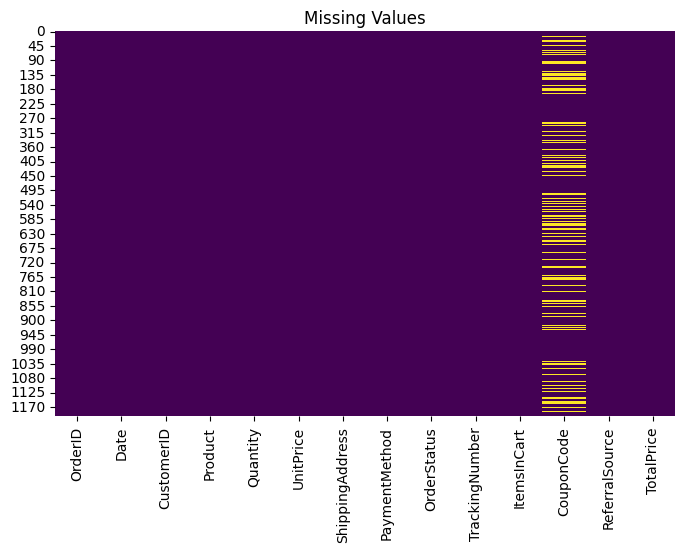

In [8]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values")
plt.show()

In [10]:
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

In [11]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


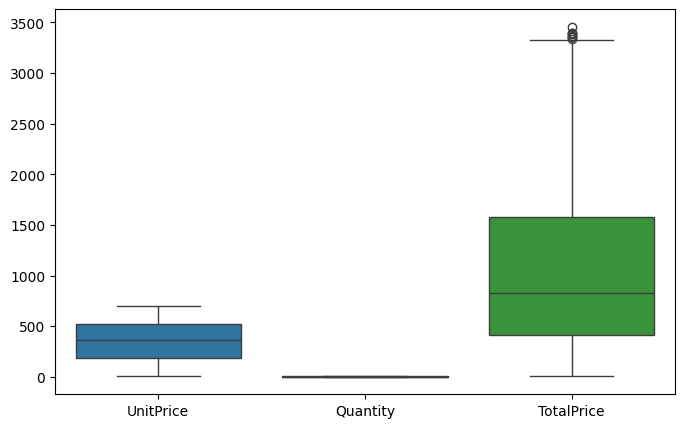

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[["UnitPrice","Quantity","TotalPrice"]])
plt.show()


In [13]:
# Feature 1: Average price per item
df["AveragePricePerItem"] = df["TotalPrice"] / df["Quantity"]

# Feature 2: Coupon used or not
df["CouponUsed"] = df["CouponCode"].apply(lambda x: "Yes" if x != "No Coupon" else "No")

# Feature 3: Order value category
df["OrderCategory"] = pd.cut(
    df["TotalPrice"],
    bins=[0, 500, 1500, 100000],
    labels=["Low", "Medium", "High"]
)

In [15]:
df.to_csv("Cleaned_Data.csv", index=False)


In [16]:
from google.colab import files

files.download("Cleaned_Data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>